## Python For Machine Learning Fall 2025
---
# K-Nearest Neighbors

The K-Nearest Neighbors (KNN) algorithm is a basic and significant machine learning method, valued for its simple concept and straightforward implementation.

## 1. The Core Idea

The main idea behind KNN is simple and intuitive: You can predict the characteristics of an unknown data point by looking at the data points that are most similar to it. In other words, things that are close together in "feature space" are likely to be related.

Imagine you're trying to guess the price of a house that's not on the market. You wouldn't look at prices from a different country; you'd look at the prices of the houses right next door on the same street. KNN does the same thing, but with data. It finds the `k` nearest neighbors to a new point and makes a prediction based on them.

## 2. Naïve Example

As a naïve example, we use Numpy to calculate the Euclidean distance between 2D points to find the closest ones. The formula for Euclidean distance between two 2D points is:
$$
d=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create a dataset
X_train = np.array([
    [2, 3], [4, 2], [5, 4], [7, 3],
    [9, 6], [8, 8], [10, 7], [11, 9]
])
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1])

To find the category of a new data point, KNN checks the new point's closest neighbors and having them "vote" on its category.

In [14]:
new_point = np.array([6, 5])

distances = np.sqrt(np.sum((X_train-new_point)**2, axis=1))

sorted_index = np.argsort(distances)
print(sorted_index)


[2 3 4 1 5 0 6 7]


Although K-Nearest Neighbors is a non-parametric method, it has two hyperparameters: the number of neighbors (`k`) and the distance metric. Since we have already chosen the distance metric, we now need to determine a specific value for `k`.

In [25]:
# Determine a suitable k-value
k = 3

k_nearest_indices = sorted_index[:k]

k_nearest_labels = y_train[k_nearest_indices]

print(k_nearest_labels)



[0 0 1]


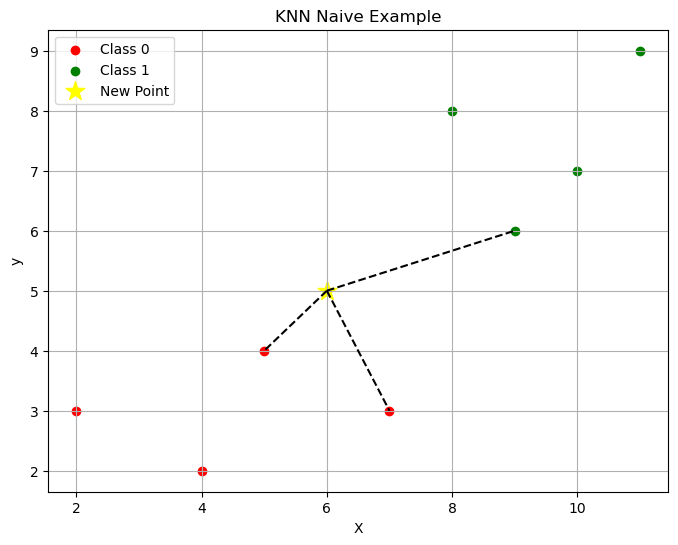

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0],
            X_train[y_train == 0][:, 1],
            c='red', label='Class 0')
plt.scatter(X_train[y_train == 1][:, 0],
            X_train[y_train == 1][:, 1],
            c='green', label='Class 1')

plt.scatter(new_point[0],
            new_point[1],
            c='yellow', marker='*',
            s=200, label='New Point')


for index in k_nearest_indices[:k]:
    plt.plot([new_point[0], X_train[index, 0]],
             [new_point[1], X_train[index, 1]],
             'k--') # k-- for black dashed line

plt.title("KNN Naive Example")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

Once we've found the 'k' nearest neighbors, what do we do? For classification, the process is **democratic**: we take a vote!

## 3. KNN in `sklearn`

Building the K-Nearest Neighbors (KNN) algorithm yourself is excellent for educational purposes. In practice, however, it is better to use an efficient library like scikit-learn that is optimized for distance calculations and finding neighbors, especially when working with large datasets. Please refer to:
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris for more information about the dataset.


In [34]:
from sklearn import datasets
iris = datasets.load_iris()

features = iris.data
labels = iris.target

print(features[:3], labels[:3])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]] [0 0 0]


Since calculations of distance are sensitive to the scale of features, we preprocess the data using standardization (Why not normalization?).

In [35]:
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(features)
print(X_std[:3])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]]


`sklearn` offers several neighbor-based machine learning algorithms in its `neighbors` module, built around three main classes: `KNeighborsClassifier` for classification, `KNeighborsRegressor` for regression, and `NearestNeighbors` for unsupervised searches.

In [41]:
from sklearn.neighbors import NearestNeighbors

The `kneighbors` method finds the `k` nearest neighbors for a data point, but only after the `fit` method has been applied to the data.

In [51]:
model = NearestNeighbors(n_neighbors=3, metric='euclidean')
model.fit(X_std)

distances, indices = model.kneighbors([[1] * 4])
print(distances[:3], labels[indices[:3]])

[[0.49140089 0.74294782 0.75692864]] [[2 2 2]]


## 4. K-Nearest Neighbors Classifier

To illustrate KNN-based classification, we will now apply the `KNeighborsClassifier` class to a set of real data.

In [52]:
# import the dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# preprocessing
standardizer = StandardScaler()
X_std = standardizer.fit_transform(X)

Using `KneighborsClassifier` to create a classifier.

In [56]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5).fit(X_std, y)

In [57]:
new_observations = [
    [0.75, 0.75, 0.75, 0.75],
    [1, 1, 1, 1]
]

knn.predict(new_observations)

array([1, 2])

## 5. Searching Hyperparameter

The parameter `k` has a significant impact on model performance. The `GridSearchCV` method in `sklearn` can be used to determine the optimal value for `k`.

In [ ]:
# Load libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

Prepare the dataset.

In [ ]:
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target

A pipeline is required for hyperparameter searching. This approach allows us to build upon existing modules rather than creating everything from scratch.This one includes two components: a preprocessing step and the k-NN model. You have the flexibility to assign custom labels to each part.

Now we can define what paramerters to search and at what range.

We can review the best parameters after the search is concluded.

## 6. Radius-based Classifer

The prediction of KNN might be subtle when the training samples are dense. In this case, distance-based method will be more stable. `sklearn` provide `RadiusNeighborsClassifier` class to create such classifiers.

One potential problem with distance-based classifiers is that no targets may be found within the specified radius.

In [ ]:
X_train = np.array([
    [1, 1], [1, 2], [2, 1], [2, 2], # Cluster 0
    [10, 10], [10, 11], [11, 10], [11, 11] # Cluster 1
])
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1])

Here we use `outlier_label` to identify points with no neighbors.

In [ ]:
new_points = np.array([
    [1.5, 1.5], # Should be classified as 0
    [6.0, 6.0]  # Should be an outlier
])

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train==0][:, 0],
            X_train[y_train==0][:, 1],
            c='blue',
            label='Class 0')
plt.scatter(X_train[y_train==1][:, 0],
            X_train[y_train==1][:, 1],
            c='red',
            label='Class 1')
plt.scatter(new_points[:, 0],
            new_points[:, 1],
            c='green',
            marker='*',
            s=200,
            label='New Points')

# Draw circles for the radius around the new points
for point in new_points:
    circle = plt.Circle(
        point, 2.0,
        color='green',
        fill=False,
        linestyle='--',
        label='Radius (2.0)')
    plt.gca().add_patch(circle)

plt.title("RadiusNeighborsClassifier: Finding an Outlier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## 7. Approximate Nearest Neighbors

The KNN method is computationally costly when we have a large dataset. There are variations of algorithms to solve this problem. Divide and conquer is a typically effective method. Here, we will use Facebook's FAISS library to do an experiment. FAISS (Facebook AI Similarity Search) is an open-source library for similarity search and clustering of vectors. It contains algorithms that search in sets of vectors of any size, up to ones that possibly do not fit in RAM.

In [ ]:
!pip install faiss-cpu

Now we can set the parameters for FAISS.

In [ ]:
n_features = X_std.shape[1]
nlist = 3
k = 2

In [ ]:
import faiss

quantizer = faiss.IndexFlatIP(n_features)
index = faiss.IndexIVFFlat(quantizer, n_features, nlist)

# Train the index and add feature vectors
index.train(X_std)
index.add(X_std)

# Create an observation
new_observation = np.array([[ 1,  1,  1,  1]])

# Search the index for the 2 nearest neighbors
distances, indices = index.search(new_observation, k)

# Show the feature vectors for the two nearest neighbors
np.array([list(X_std[i]) for i in indices[0]])

Now let's see how FAISS works.

In [ ]:
# import packages
import numpy as np
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.datasets import make_blobs

In [ ]:
np.random.seed(42)
X, y = make_blobs(n_samples=1000, centers=15, n_features=2, random_state=42, cluster_std=0.8)
X = X.astype('float32') # FAISS requires float32

D = X.shape[1]
N = X.shape[0]

nlist = 15
quantizer = faiss.IndexFlatL2(D)
index = faiss.IndexIVFFlat(quantizer, D, nlist, faiss.METRIC_L2)

index.train(X)
index.add(X)

centroids = index.quantizer.reconstruct_n(0, nlist)

_, list_ids = quantizer.search(X, 1)
list_ids = list_ids.flatten()

query_point = np.array([[2.5, -7.5]], dtype='float32')
nprobe = 3

distances, cell_ids = quantizer.search(query_point, nprobe)
probed_cell_ids = cell_ids.flatten()

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
fig.suptitle("How FAISS Works: Indexing and Searching with Inverted Lists (IndexIVFFlat)", fontsize=16)

# ---
ax1.set_title(f"Step 1: Indexing (Partitioning into {nlist} Lists)", fontsize=12)
vor = Voronoi(centroids)
voronoi_plot_2d(vor, ax=ax1, show_vertices=False, line_colors='gray', line_width=2, point_size=0)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=list_ids, palette='tab20', ax=ax1, s=30, alpha=0.7, legend=False)
ax1.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=150, edgecolor='white', label=f'{nlist} Centroids')
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend()

#----
ax2.set_title(f"Step 2: Searching (Checking only {nprobe} nearest lists)", fontsize=12)
# Highlight the cells that will be searched
for region_index in probed_cell_ids:
    region = vor.regions[vor.point_region[region_index]]
    if not -1 in region:
        polygon = [vor.vertices[i] for i in region]
        ax2.fill(*zip(*polygon), alpha=0.2, color='orange', edgecolor='orange')

sns.scatterplot(x=X[:, 0], y=X[:, 1], color='lightgray', ax=ax2, s=30, alpha=0.5)

# Highlight data points within the searched cells
searched_points_mask = np.isin(list_ids, probed_cell_ids)
sns.scatterplot(x=X[searched_points_mask, 0], y=X[searched_points_mask, 1], hue=list_ids[searched_points_mask], palette='tab20', ax=ax2, s=40, alpha=0.9, legend=False)
ax2.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=150, edgecolor='white', label='Centroids')
ax2.scatter(query_point[:, 0], query_point[:, 1], c='red', marker='*', s=300, edgecolor='black', label='Query Point')
ax2.set_xlabel("Feature 1")
ax2.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()